In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from utils import process_remote, process_insitu, fuse_datasets
from config import no_outlier_check, remote_features, insitu_features1, insitu_features2

In [ ]:
def prepare_and_correlate(insitu_df, remote_df, insitu_vars, remote_vars, corr_method='spearman'):
    """
    Filters data by selected variables, merges on datetime index, and calculates correlation.
    """
    # filter columns based on user selection
    filtered_insitu = insitu_df[insitu_vars]
    filtered_remote = remote_df[remote_vars]
    
    # merge both datasets using their datetime index
    merged_data = pd.merge(
        filtered_insitu, 
        filtered_remote, 
        left_index=True, 
        right_index=True, 
        how='inner'
    )
    
    # calculate the correlation matrix
    correlation_matrix = merged_data.corr(method=corr_method)
    
    return correlation_matrix

def plot_lower_triangle_heatmap(corr_matrix, corr_method='spearman'):
    """
    Generates a styled lower-triangle heatmap using seaborn.
    """
    # create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # define a custom diverging colormap (blue to red)
    custom_cmap = sns.diverging_palette(250, 15, as_cmap=True)
    
    # create custom annotations (hides weak correlations)
    annotations = corr_matrix.map(
        lambda val: f"{val:.2f}" if abs(val) >= 0.40 else ""
    ).to_numpy()
    
    # initialize the matplotlib figure
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # plot the heatmap
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=custom_cmap, 
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        annot=annotations, 
        fmt="", 
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8, "label": f"Coeficiente de {corr_method.capitalize()}"}
    )
    
    # adjust labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def generate_correlation_analysis(insitu_df, remote_df, insitu_vars, remote_vars, corr_method='spearman'):
    """
    Main function to orchestrate data preparation and plotting.
    """
    # execute data preparation and correlation
    corr_matrix = prepare_and_correlate(
        insitu_df, 
        remote_df, 
        insitu_vars, 
        remote_vars, 
        corr_method
    )
    
    # execute the plotting function
    plot_lower_triangle_heatmap(corr_matrix, corr_method)


In [3]:
# North
remote_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=True,
    window_length=14
)
insitu_df1 = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=False,
    smooth=False
)
fused_df1 = fuse_datasets(
    insitu=insitu_df1,
    remote=remote_df1,
    startDate='2024-05-01',
    endDate='2026-05-01',
    features=remote_features+insitu_features1
)
z_df1 = fused_df1.apply(zscore, nan_policy='omit')

# South
remote_df2 = process_remote(
    filepath='../data/processed/satellites/SDH2_S2_20m_2023-10_2026-06.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    interpolation=True,
    stats=True,
    smooth=False,
    window_length=14
)
insitu_df2 = process_insitu(
    filepath='../data/processed/in-situ/SDH2_daily-insitu-data.csv',
    duplicates=True,
    reindex=True,
    outliers=True,
    ignore_vars=no_outlier_check,
    interpolation=True,
    smooth=False
)
fused_df2 = fuse_datasets(
    insitu=insitu_df2,
    remote=remote_df2,
    startDate='2024-05-01',
    endDate='2026-05-01',
    features=remote_features+insitu_features2
)
z_df2 = fused_df2.apply(zscore, nan_policy='omit')


/Users/pibonacic/Documents/projects/groundwater-remote-sensing/code/preparation.py:112: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = zscore(df_copy[cols_to_check], nan_policy='omit')


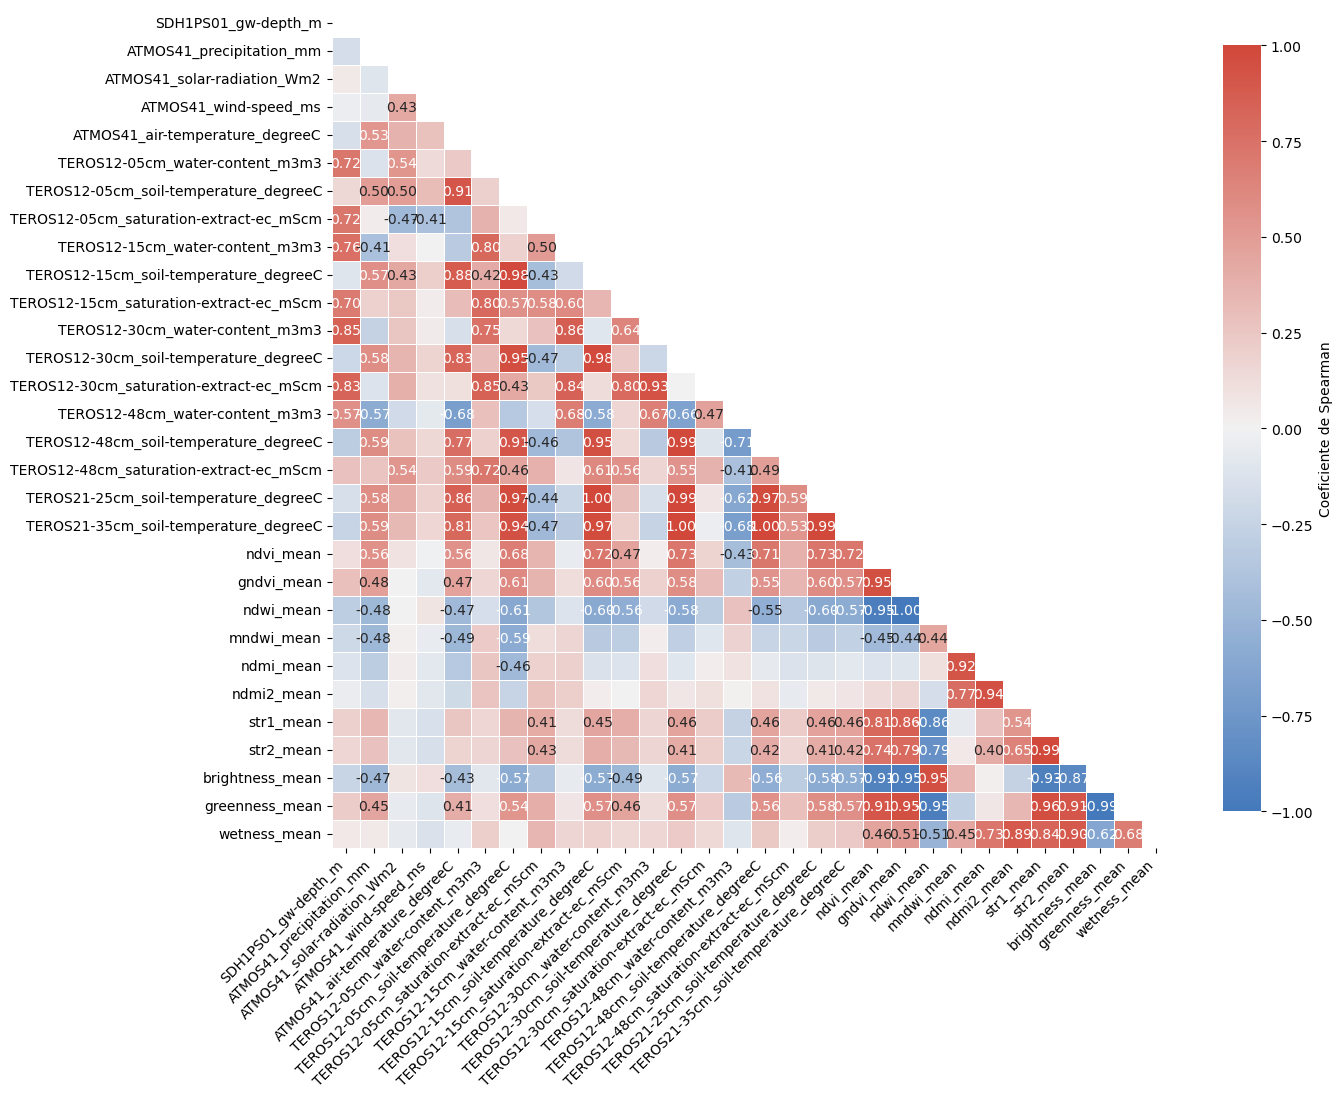

In [4]:
corr = generate_correlation_analysis(
    insitu_df=insitu_df1,
    remote_df=remote_df1,
    insitu_vars=insitu_features1,
    remote_vars=remote_features,
    corr_method='spearman'
)

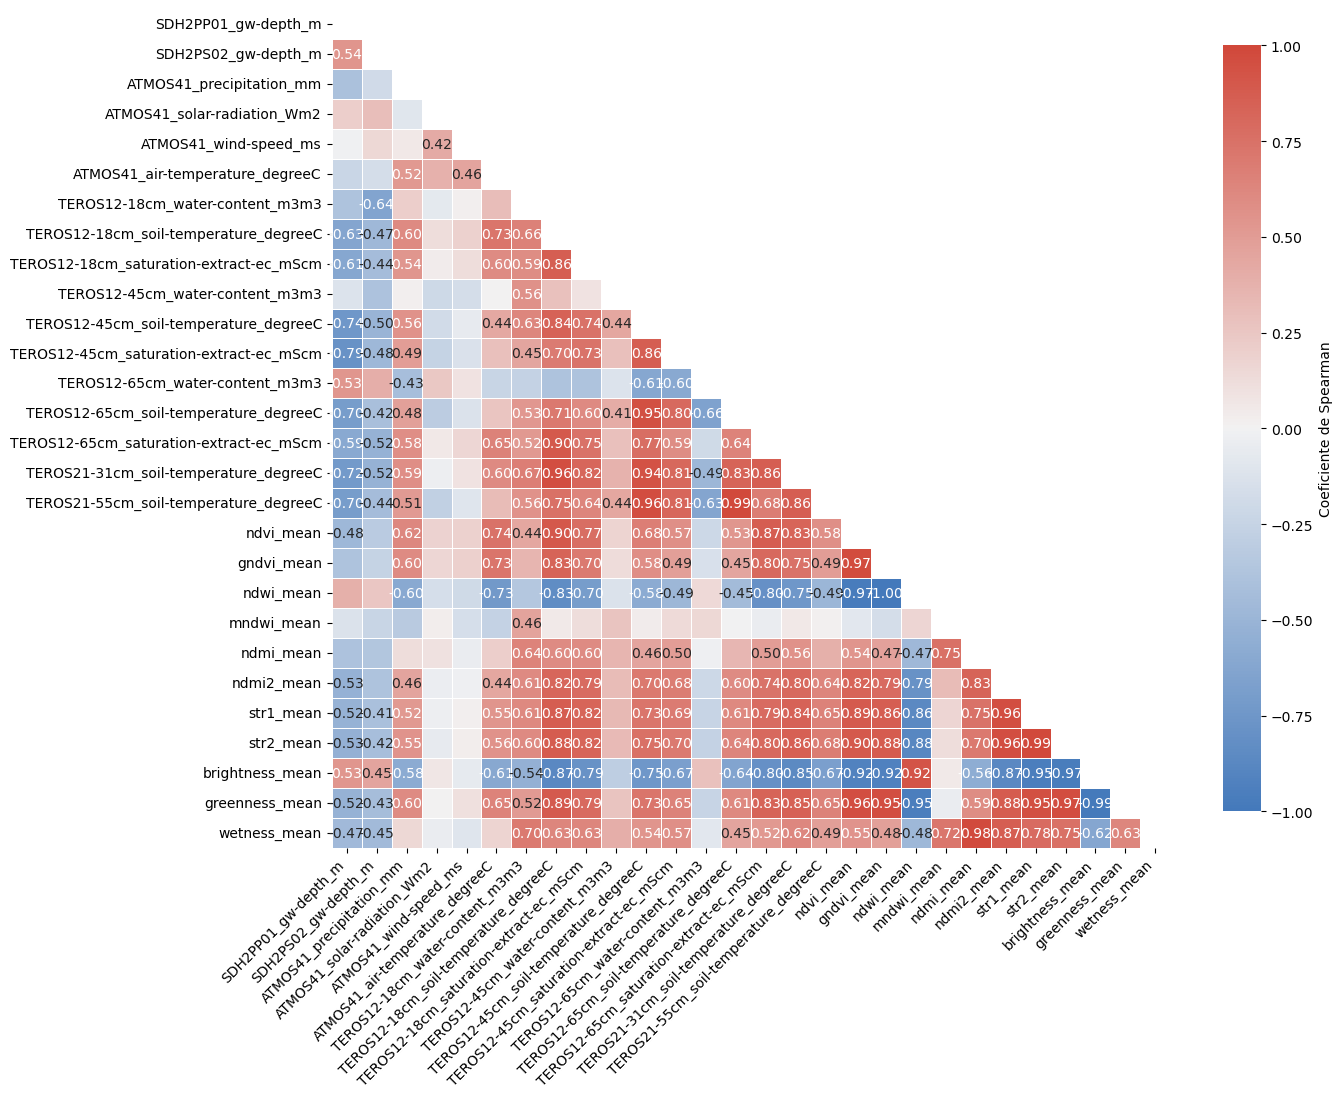

In [5]:
corr = generate_correlation_analysis(
    insitu_df=insitu_df2,
    remote_df=remote_df2,
    insitu_vars=insitu_features2,
    remote_vars=remote_features,
    corr_method='spearman'
)